IPs: dict_keys(['axi_gpio_0', 'i2s_receiver_0', 'i2s_transmitter_0'])

Checking I2C bus 1...
0  1  2  3  4  5  6  7  8  9  a  b  c  d  e  f
00:          -- -- -- -- -- -- -- -- -- -- -- -- -- 
10: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
20: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
30: -- -- -- -- -- -- -- -- -- -- -- 3b -- -- -- -- 
40: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
50: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
60: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
70: -- -- -- -- -- -- -- --

Configuring ADAU1761 PLL...
PLL raw: ['0x2', '0x71', '0x2', '0x3c', '0x21', '0x3'] locked: True
PLL locked and codec core clock enabled.
Codec output configured.

Configuring RX/TX...

RX registers:
0x00: 0x00010000
0x04: 0x00010201
0x08: 0x00000001
0x0C: 0x00000000
0x10: 0x00000000
0x14: 0x00000001
0x20: 0x00000001
0x30: 0x00000001
0x34: 0x00000002
0x38: 0x00000003
0x3C: 0x00000004

TX registers:
0x00: 0x00010000
0x04: 0x00010201
0x08: 0x00000001
0x0C: 0x

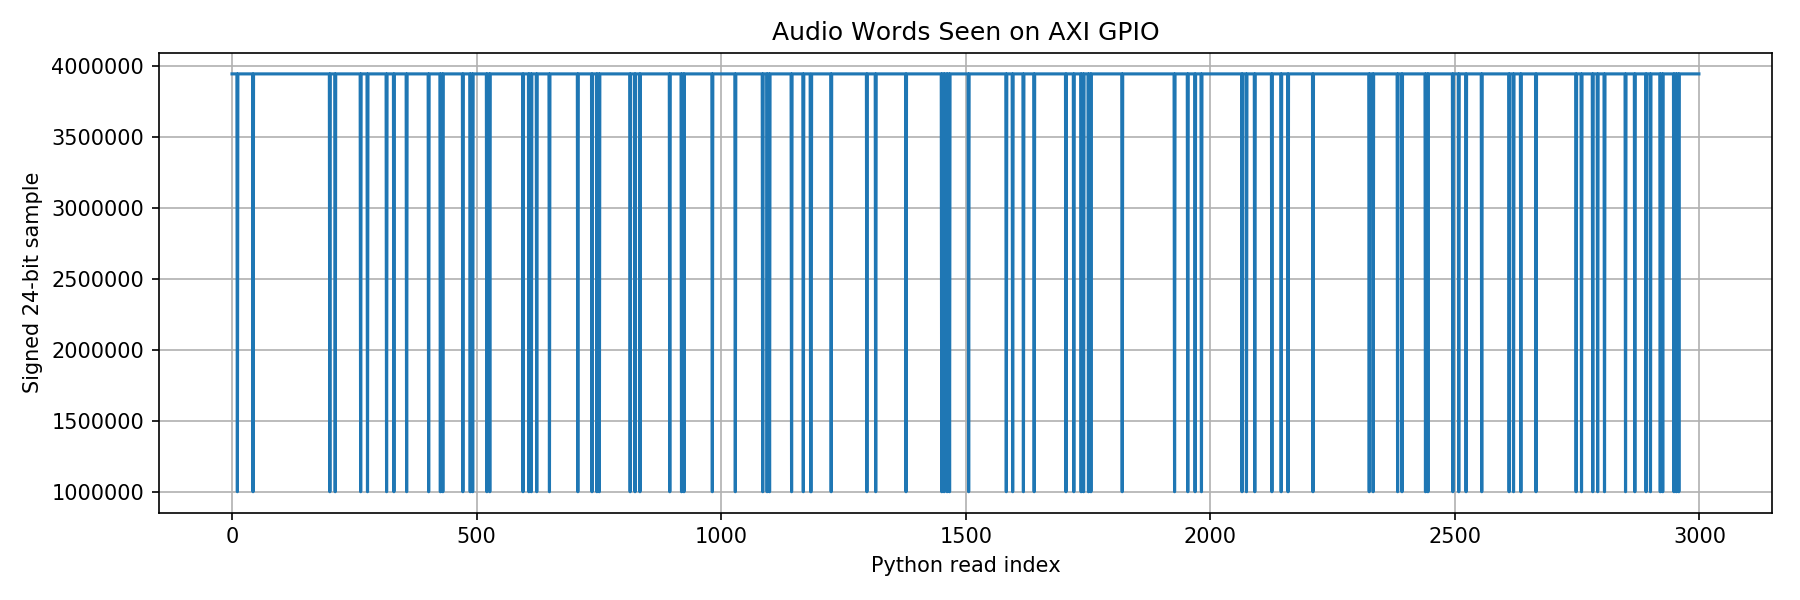

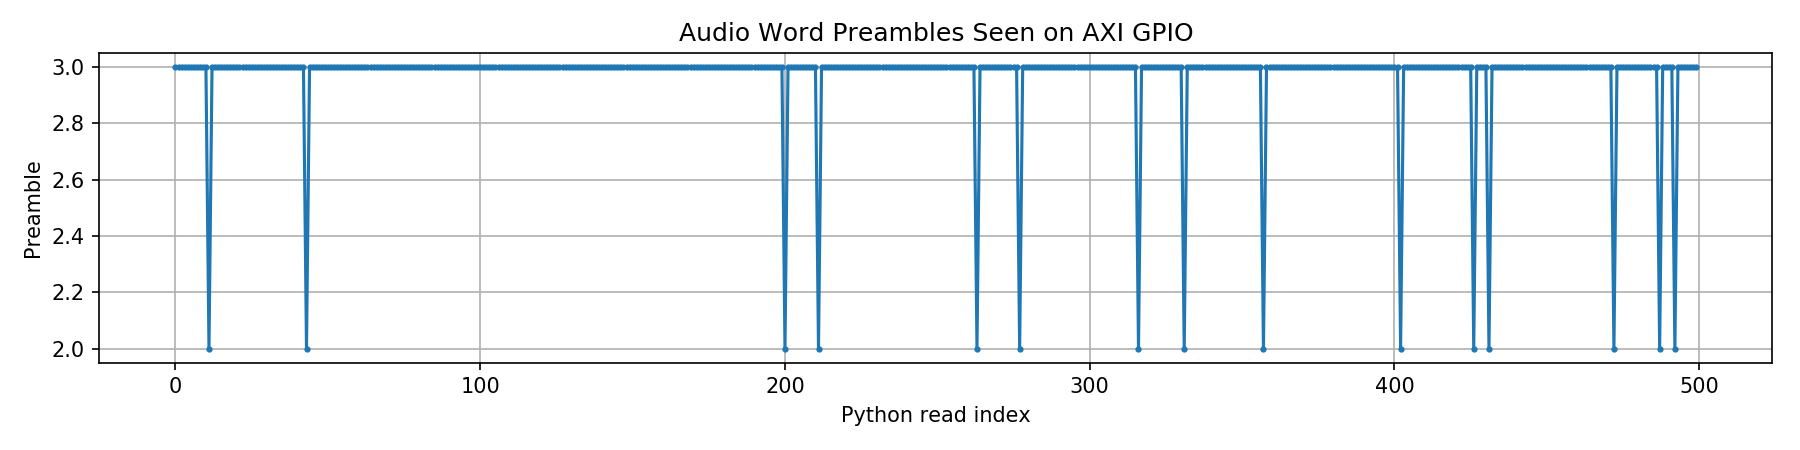

In [1]:
from pynq import Overlay
import subprocess
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

BITFILE = "full.bit"  # change if needed

ol = Overlay(BITFILE)
print("IPs:", ol.ip_dict.keys())

rx = ol.i2s_receiver_0
tx = ol.i2s_transmitter_0
dbg = ol.axi_gpio_0


def run_cmd(cmd, check=True):
    p = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        universal_newlines=True
    )
    if check and p.returncode != 0:
        raise RuntimeError(
            "Command failed:\n{}\nstdout:\n{}\nstderr:\n{}".format(
                " ".join(cmd), p.stdout, p.stderr
            )
        )
    return p.stdout.strip()


def i2c_raw(bytes_list):
    payload = ["0x{:02x}".format(b & 0xFF) for b in bytes_list]
    cmd = ["i2ctransfer", "-y", "1", "w{}@0x3b".format(len(payload))] + payload
    run_cmd(cmd)
    time.sleep(0.002)


def codec_reg(reg, val):
    i2c_raw([0x40, reg & 0xFF, val & 0xFF])


def read_pll():
    out = run_cmd([
        "i2ctransfer", "-y", "1",
        "w2@0x3b", "0x40", "0x02",
        "r6"
    ])
    vals = [int(x, 16) for x in out.split()]
    locked = bool(vals[5] & 0x02)
    print("PLL raw:", [hex(v) for v in vals], "locked:", locked)
    return locked


def configure_codec_output():
    print("\nChecking I2C bus 1...")
    print(run_cmd(["i2cdetect", "-y", "-r", "1"]))

    print("\nConfiguring ADAU1761 PLL...")
    codec_reg(0x00, 0x0E)
    i2c_raw([0x40, 0x02, 0x02, 0x71, 0x02, 0x3C, 0x21, 0x03])

    locked = False
    for _ in range(50):
        locked = read_pll()
        if locked:
            break
        time.sleep(0.05)

    if not locked:
        raise RuntimeError("ADAU1761 PLL did not lock.")

    codec_reg(0x00, 0x0F)
    print("PLL locked and codec core clock enabled.")

    writes = [
        (0x04, 0x00),
        (0x06, 0x00),
        (0x08, 0xB3),
        (0x09, 0xB3),
        (0x0A, 0x01),
        (0x0E, 0x20),

        # Codec slave mode: FPGA drives BCLK/LRCLK
        (0x0F, 0x00),

        (0x13, 0x33),
        (0x23, 0x03),
        (0x24, 0x03),

        # Serial routing
        (0xF2, 0x01),
        (0xF3, 0x01),

        # Clocks / DSP
        (0xF5, 0x01),
        (0xF6, 0x01),
        (0xF9, 0x7F),
        (0xFA, 0x03),

        # Output path
        (0x17, 0x00),
        (0x19, 0x00),
        (0x16, 0x21),
        (0x18, 0x41),
        (0x1D, 0xE7),
        (0x1E, 0xE7),
        (0x1F, 0xE7),
        (0x20, 0xE7),
    ]

    for reg, val in writes:
        codec_reg(reg, val)

    print("Codec output configured.")


def configure_rx_tx():
    print("\nConfiguring RX/TX...")

    rx.mmio.write(0x08, 0)
    tx.mmio.write(0x08, 0)
    time.sleep(0.2)

    rx.mmio.write(0x10, 0)
    tx.mmio.write(0x10, 0)

    rx.mmio.write(0x14, 0xFFFFFFFF)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    rx.mmio.write(0x20, 1)
    tx.mmio.write(0x20, 1)

    # Leave TX mux defaults alone.
    tx.mmio.write(0x0C, 1)

    rx.mmio.write(0x14, 0xFFFFFFFF)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    time.sleep(0.1)

    tx.mmio.write(0x08, 1)
    time.sleep(0.2)
    rx.mmio.write(0x08, 1)
    time.sleep(0.5)


def dump_ip(ip, name):
    print("\n{} registers:".format(name))
    for off in [0x00, 0x04, 0x08, 0x0C, 0x10, 0x14, 0x20, 0x30, 0x34, 0x38, 0x3C]:
        try:
            print("0x{:02X}: 0x{:08X}".format(off, ip.mmio.read(off)))
        except Exception:
            pass


def unpack_audio_word(raw):
    """
    Audio word:
      [31:28] = control
      [27:4]  = signed 24-bit sample
      [3:0]   = preamble
    """
    control = (raw >> 28) & 0xF
    sample24 = (raw >> 4) & 0xFFFFFF
    preamble = raw & 0xF

    if sample24 & 0x800000:
        sample24 -= 1 << 24

    return sample24, preamble, control


def capture(duration=3.0):
    raws = []
    samples = []
    preambles = []
    controls = []

    start = time.time()

    while time.time() - start < duration:
        raw = int(dbg.channel1.read())
        sample, preamble, control = unpack_audio_word(raw)

        raws.append(raw)
        samples.append(sample)
        preambles.append(preamble)
        controls.append(control)

    return (
        np.array(raws, dtype=np.uint32),
        np.array(samples, dtype=np.int32),
        np.array(preambles, dtype=np.int32),
        np.array(controls, dtype=np.int32),
    )


configure_codec_output()
configure_rx_tx()

dump_ip(rx, "RX")
dump_ip(tx, "TX")

print("\nCapturing GPIO as audio tdata...")
raws, samples, preambles, controls = capture(duration=3.0)

print("Captured:", len(samples))
print("Unique controls:", sorted(set(controls.tolist())))
print("Unique preambles:", sorted(set(preambles.tolist())))
print("Sample min:", samples.min())
print("Sample max:", samples.max())
print("Unique sample count:", len(set(samples.tolist())))

print("\nFirst 20 raw words:")
for x in raws[:20]:
    print("0x{:08X}".format(int(x)))

print("\nFirst 20 decoded samples:")
print(samples[:20])

plt.figure(figsize=(12, 4))
plt.plot(samples[:3000])
plt.title("Audio Words Seen on AXI GPIO")
plt.xlabel("Python read index")
plt.ylabel("Signed 24-bit sample")
plt.grid(True)
plt.tight_layout()
plt.savefig("/home/xilinx/audio_gpio_samples.png", dpi=150)
plt.close()
display(Image(filename="/home/xilinx/audio_gpio_samples.png"))

plt.figure(figsize=(12, 3))
plt.plot(preambles[:500], marker="o", markersize=2)
plt.title("Audio Word Preambles Seen on AXI GPIO")
plt.xlabel("Python read index")
plt.ylabel("Preamble")
plt.grid(True)
plt.tight_layout()
plt.savefig("/home/xilinx/audio_gpio_preambles.png", dpi=150)
plt.close()
display(Image(filename="/home/xilinx/audio_gpio_preambles.png"))

IPs: dict_keys(['axi_gpio_0', 'axi_gpio_gain', 'i2s_receiver_0', 'i2s_transmitter_0'])
Gain GPIO: <pynq.lib.axigpio.AxiGPIO object at 0xaf2104f0>

Checking I2C bus 1...
0  1  2  3  4  5  6  7  8  9  a  b  c  d  e  f
00:          -- -- -- -- -- -- -- -- -- -- -- -- -- 
10: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
20: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
30: -- -- -- -- -- -- -- -- -- -- -- 3b -- -- -- -- 
40: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
50: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
60: -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
70: -- -- -- -- -- -- -- --

Configuring ADAU1761 PLL...
PLL raw: ['0x2', '0x71', '0x2', '0x3c', '0x21', '0x3'] locked: True
PLL locked and codec core clock enabled.
Codec output configured.
Set gains:
  low = 1.0 32768
  mid = 1.0 32768
  high= 1.0 32768

Configuring RX/TX...

RX registers:
0x00: 0x00010000
0x04: 0x00010201
0x08: 0x00000001
0x0C: 0x00000000
0x10: 0x00000000
0x14: 0x00000001
0x20: 0x00000001
0

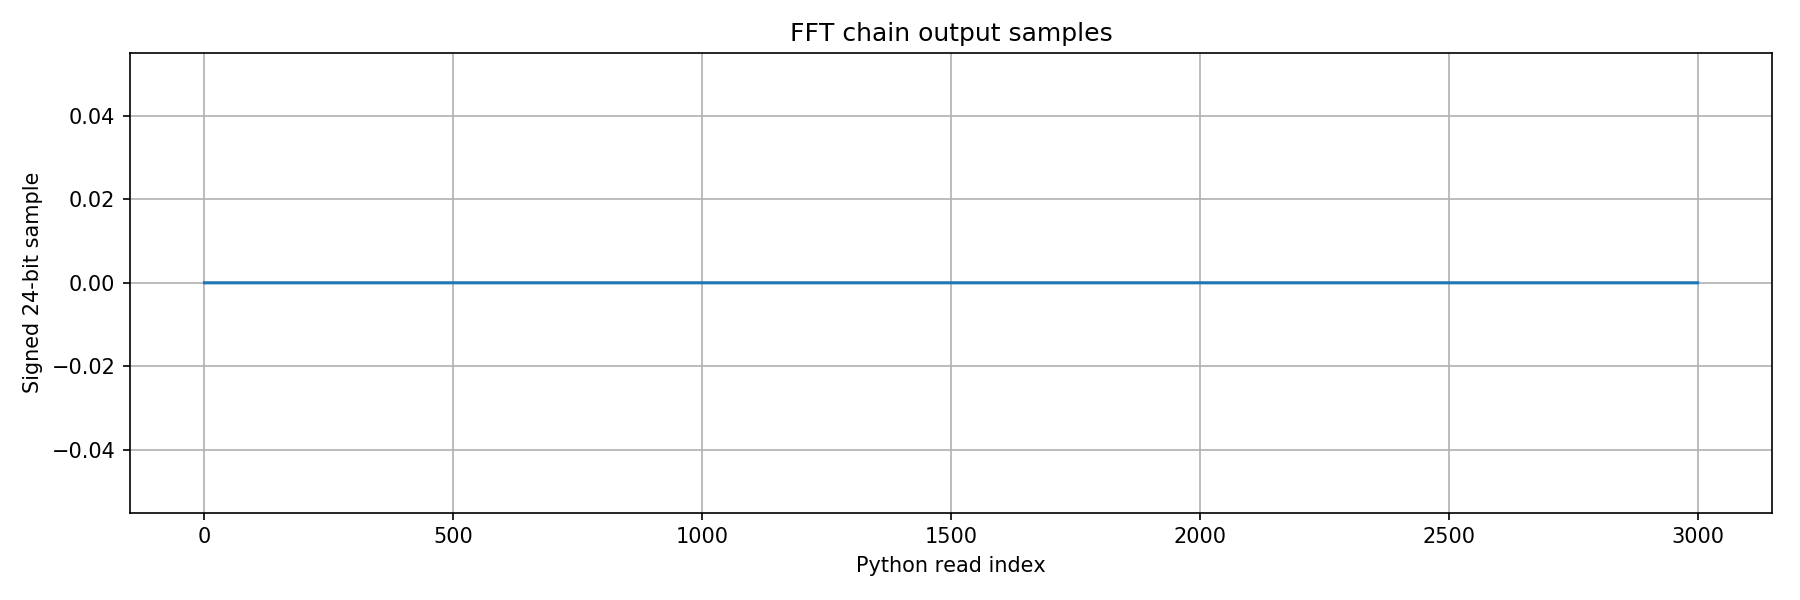


Now try changing gains, then rerun capture.
Example:
  set_eq_gains(low=1.5, mid=1.0, high=1.0)
  raws = capture_gpio(duration=3.0)
  samples, preambles, controls = analyze_as_audio(raws, 'low boost')


In [1]:
from pynq import Overlay
import subprocess
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

BITFILE = "fullb.bit"   # change to your bitstream name

ol = Overlay(BITFILE)
print("IPs:", ol.ip_dict.keys())

rx = ol.i2s_receiver_0
tx = ol.i2s_transmitter_0
dbg = ol.axi_gpio_0

gain_gpio = None
if "axi_gpio_gain" in ol.ip_dict:
    gain_gpio = ol.axi_gpio_gain
elif "axi_gpio_1" in ol.ip_dict:
    gain_gpio = ol.axi_gpio_1

print("Gain GPIO:", gain_gpio)


# ------------------------------------------------------------
# I2C / Codec helpers
# ------------------------------------------------------------

def run_cmd(cmd, check=True):
    p = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        universal_newlines=True
    )
    if check and p.returncode != 0:
        raise RuntimeError(
            "Command failed:\n{}\nstdout:\n{}\nstderr:\n{}".format(
                " ".join(cmd), p.stdout, p.stderr
            )
        )
    return p.stdout.strip()


def i2c_raw(bytes_list):
    payload = ["0x{:02x}".format(b & 0xFF) for b in bytes_list]
    cmd = ["i2ctransfer", "-y", "1", "w{}@0x3b".format(len(payload))] + payload
    run_cmd(cmd)
    time.sleep(0.002)


def codec_reg(reg, val):
    i2c_raw([0x40, reg & 0xFF, val & 0xFF])


def read_pll():
    out = run_cmd([
        "i2ctransfer", "-y", "1",
        "w2@0x3b", "0x40", "0x02",
        "r6"
    ])
    vals = [int(x, 16) for x in out.split()]
    locked = bool(vals[5] & 0x02)
    print("PLL raw:", [hex(v) for v in vals], "locked:", locked)
    return locked


def configure_codec_output():
    print("\nChecking I2C bus 1...")
    print(run_cmd(["i2cdetect", "-y", "-r", "1"]))

    print("\nConfiguring ADAU1761 PLL...")
    codec_reg(0x00, 0x0E)

    # PLL config for 10 MHz audio clock on U5
    i2c_raw([0x40, 0x02, 0x02, 0x71, 0x02, 0x3C, 0x21, 0x03])

    locked = False
    for _ in range(50):
        locked = read_pll()
        if locked:
            break
        time.sleep(0.05)

    if not locked:
        raise RuntimeError("ADAU1761 PLL did not lock. Check audio_clk_10MHz on U5.")

    codec_reg(0x00, 0x0F)
    print("PLL locked and codec core clock enabled.")

    writes = [
        (0x04, 0x00),
        (0x06, 0x00),
        (0x08, 0xB3),
        (0x09, 0xB3),
        (0x0A, 0x01),
        (0x0E, 0x20),

        # Codec slave mode: FPGA drives BCLK/LRCLK.
        (0x0F, 0x00),

        # ADC/DAC
        (0x13, 0x33),
        (0x23, 0x03),
        (0x24, 0x03),

        # Serial routing
        (0xF2, 0x01),  # SDATA_IN -> DAC
        (0xF3, 0x01),  # ADC -> SDATA_OUT

        # DSP/core clocks
        (0xF5, 0x01),
        (0xF6, 0x01),
        (0xF9, 0x7F),
        (0xFA, 0x03),

        # Output mixer/headphone path
        (0x17, 0x00),
        (0x19, 0x00),
        (0x16, 0x21),
        (0x18, 0x41),
        (0x1D, 0xE7),
        (0x1E, 0xE7),
        (0x1F, 0xE7),
        (0x20, 0xE7),
    ]

    for reg, val in writes:
        codec_reg(reg, val)

    print("Codec output configured.")


# ------------------------------------------------------------
# Gain helpers
# ------------------------------------------------------------

def gain_to_q15(gain):
    val = int(round(gain * 32768))
    return max(0, min(65535, val))


def set_eq_gains(low=1.0, mid=1.0, high=1.0):
    if gain_gpio is None:
        print("No gain GPIO found. Skipping gain setup.")
        return

    low_q = gain_to_q15(low)
    mid_q = gain_to_q15(mid)
    high_q = gain_to_q15(high)

    # Expected mapping:
    # channel1 bits [15:0] low, [31:16] mid
    # channel2 bits [15:0] high
    gain_gpio.channel1.write((mid_q << 16) | low_q, 0xFFFFFFFF)
    gain_gpio.channel2.write(high_q, 0x0000FFFF)

    print("Set gains:")
    print("  low =", low, low_q)
    print("  mid =", mid, mid_q)
    print("  high=", high, high_q)


# ------------------------------------------------------------
# RX/TX setup
# ------------------------------------------------------------

def dump_ip(ip, name):
    print("\n{} registers:".format(name))
    for off in [0x00, 0x04, 0x08, 0x0C, 0x10, 0x14, 0x20, 0x30, 0x34, 0x38, 0x3C]:
        try:
            print("0x{:02X}: 0x{:08X}".format(off, ip.mmio.read(off)))
        except Exception:
            pass


def configure_rx_tx():
    print("\nConfiguring RX/TX...")

    rx.mmio.write(0x08, 0)
    tx.mmio.write(0x08, 0)
    time.sleep(0.2)

    rx.mmio.write(0x10, 0)
    tx.mmio.write(0x10, 0)

    rx.mmio.write(0x14, 0xFFFFFFFF)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    # Critical divider from earlier working tests
    rx.mmio.write(0x20, 1)
    tx.mmio.write(0x20, 1)

    # Keep TX channel mux defaults. Do not overwrite 0x30/0x34/0x38/0x3C.
    tx.mmio.write(0x0C, 1)

    rx.mmio.write(0x14, 0xFFFFFFFF)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    time.sleep(0.1)

    # TX first, then RX
    tx.mmio.write(0x08, 1)
    time.sleep(0.2)
    rx.mmio.write(0x08, 1)
    time.sleep(0.5)

    dump_ip(rx, "RX")
    dump_ip(tx, "TX")


# ------------------------------------------------------------
# Decode helpers
# ------------------------------------------------------------

def unpack_audio_word(raw):
    control = (raw >> 28) & 0xF
    sample24 = (raw >> 4) & 0xFFFFFF
    preamble = raw & 0xF

    if sample24 & 0x800000:
        sample24 -= 1 << 24

    return sample24, preamble, control


def decode_debug_word(raw):
    return {
        "raw": raw,
        "signature": (raw >> 28) & 0xF,
        "tvalid": bool(raw & (1 << 0)),
        "tready": bool(raw & (1 << 1)),
        "fire": bool(raw & (1 << 2)),
        "tid": (raw >> 3) & 0x7,
        "sclk": bool(raw & (1 << 9)),
        "lrclk": bool(raw & (1 << 10)),
        "sdata": bool(raw & (1 << 11)),
        "aud_mrst": bool(raw & (1 << 12)),
        "stream_aresetn": bool(raw & (1 << 13)),
        "saw_fire": bool(raw & (1 << 16)),
        "saw_sdata_high": bool(raw & (1 << 17)),
        "saw_sdata_edge": bool(raw & (1 << 18)),
        "tdata27": bool(raw & (1 << 19)),
        "tdata26": bool(raw & (1 << 20)),
        "tdata4": bool(raw & (1 << 21)),
        "preamble": (raw >> 22) & 0xF,
    }


def capture_gpio(duration=3.0):
    raws = []
    start = time.time()

    while time.time() - start < duration:
        raws.append(int(dbg.channel1.read()))

    return np.array(raws, dtype=np.uint32)


def analyze_as_audio(raws, label):
    samples = []
    preambles = []
    controls = []

    for raw in raws:
        sample, preamble, control = unpack_audio_word(int(raw))
        samples.append(sample)
        preambles.append(preamble)
        controls.append(control)

    samples = np.array(samples, dtype=np.int32)
    preambles = np.array(preambles, dtype=np.int32)
    controls = np.array(controls, dtype=np.int32)

    print("\n{} interpreted as audio words:".format(label))
    print("Captured:", len(samples))
    print("Unique controls:", sorted(set(controls.tolist())))
    print("Unique preambles:", sorted(set(preambles.tolist())))
    print("Sample min:", samples.min())
    print("Sample max:", samples.max())
    print("Unique sample count:", len(set(samples.tolist())))

    print("\nFirst 20 raw words:")
    for x in raws[:20]:
        print("0x{:08X}".format(int(x)))

    print("\nFirst 20 samples:")
    print(samples[:20])

    plt.figure(figsize=(12, 4))
    plt.plot(samples[:3000])
    plt.title("{} samples".format(label))
    plt.xlabel("Python read index")
    plt.ylabel("Signed 24-bit sample")
    plt.grid(True)
    plt.tight_layout()
    path = "/home/xilinx/audio_fft_chain_samples.png"
    plt.savefig(path, dpi=150)
    plt.close()
    display(Image(filename=path))

    return samples, preambles, controls


def analyze_as_debug(raws):
    total = len(raws)
    ready = 0
    fire = 0
    sdata_high = 0
    saw_fire = False
    saw_sdata_high = False
    saw_sdata_edge = False
    preambles = set()
    signatures = set()

    for raw in raws:
        d = decode_debug_word(int(raw))
        signatures.add(d["signature"])
        preambles.add(d["preamble"])
        if d["tready"]:
            ready += 1
        if d["fire"]:
            fire += 1
        if d["sdata"]:
            sdata_high += 1
        saw_fire = saw_fire or d["saw_fire"]
        saw_sdata_high = saw_sdata_high or d["saw_sdata_high"]
        saw_sdata_edge = saw_sdata_edge or d["saw_sdata_edge"]

    d = decode_debug_word(int(raws[-1]))

    print("\nGPIO interpreted as debug probe:")
    print("total reads:", total)
    print("signatures seen:", sorted(hex(x) for x in signatures))
    print("tready reads:", ready)
    print("fire reads:", fire)
    print("sdata high reads:", sdata_high)
    print("preambles seen:", sorted(preambles))
    print("saw_fire:", saw_fire)
    print("saw_sdata_high:", saw_sdata_high)
    print("saw_sdata_edge:", saw_sdata_edge)

    print("\nFinal debug raw: 0x{:08X}".format(d["raw"]))
    print("signature:", hex(d["signature"]))
    print("tvalid:", d["tvalid"])
    print("tready:", d["tready"])
    print("fire:", d["fire"])
    print("tid:", d["tid"])
    print("sclk:", d["sclk"])
    print("lrclk:", d["lrclk"])
    print("sdata:", d["sdata"])
    print("aud_mrst:", d["aud_mrst"])
    print("stream_aresetn:", d["stream_aresetn"])
    print("preamble:", hex(d["preamble"]))


# ------------------------------------------------------------
# Run test
# ------------------------------------------------------------

configure_codec_output()

# Unity gain baseline
set_eq_gains(low=1.0, mid=1.0, high=1.0)

configure_rx_tx()

print("\nCapturing GPIO...")
raws = capture_gpio(duration=3.0)

# Auto-detect whether GPIO looks like debug probe or audio word
first_sig = (int(raws[-1]) >> 28) & 0xF

if first_sig == 0xA:
    analyze_as_debug(raws)
else:
    samples, preambles, controls = analyze_as_audio(raws, "FFT chain output")

print("\nNow try changing gains, then rerun capture.")
print("Example:")
print("  set_eq_gains(low=1.5, mid=1.0, high=1.0)")
print("  raws = capture_gpio(duration=3.0)")
print("  samples, preambles, controls = analyze_as_audio(raws, 'low boost')")